In [ ]:
# 구글 마운트

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import time

# flow 시각화 함수 정의
def drawFlow(img, flow, step=16):
    # Farneback optical flow 결과를 시각화하는 함수
    # 특정 간격(step)마다 화살표를 그려 움직임 벡터를 표시
    h, w = img.shape[:2]
    # .shape >> (h, w, c)
    # .shape[:2] >> (h, w)

    # 16 pixel 간격의 그리드를 가진 인덱스 구하기(좌표: y, x)
    idx_y, idx_x = np.mgrid[step//2:h:step, step//2:w:step].astype(np.int32)
    # np.mgrid (mesh-grid) (like 모눈종이)
    # [시작값: 끝 값: 간격(증가값)]
    # step//2 시작 지점을 정수 나눗셈으로 안전하게 지정
    # 시작점: step//2 (=8), 끝: h(이미지 높이), 간격(step)

    # y, x 를 묶어서 (N, 2) 형태의 좌표 목록(x, y 순서) 재구성
    indices = np.stack((idx_x, idx_y), axis=-1).reshape(-1, 2)
    # reshape(-1, 2)
    # >> 2 : 한 칸에 무조건 [x, y] 2개 들어가게 만든다.
    # >> -1 : 전체 점이 몇 개든 1줄로 줄 세운다.

    # 화살표 색상(녹색)
    arrow_color = (0, 255, 0)

    for x, y in indices:    # 각 그리드 인덱스 순회(x : 열, y : 행)
        # 1. 각 그리드 인덱스 위치에 시작점(점) 그리기 (녹색)
        cv2.circle(img, (x, y), 1, arrow_color, -1)

        # 움직임 벡터 추출 **밀집 광학 흐름의 핵심**
        # 2. 각 그리드 인덱스에 해당하는 flow 결과 값(이동 거리) 얻기
            # flow 배열 (h, w, 2) 형태. 2 : dx, dy
            # (h, w, 2)
            # h 이미지의 세로 높이=행 개수
            # w 이미지의 가로 너비=열 개수
            # 2 channels 각 픽셀 위치에 저장된 2개의 데이터, dx, dy
            # dx, dy : 0번째 가로로 얼마나 움직였지?, 1번째 세로로 얼마나 움직였지?
            # 왜 담고 있니? 모든 픽셀 자리에 (dx, dy) 벡터 숫자 세트를 담고 있다.
            # dx, dy는 flow 형태이므로 정수형으로 변환

        dx, dy = flow[y, x].astype(np.int32)
        # int32 >> 픽셀 단위로 넣기 위해 정수형 / 최대한 많은 정보 담기 위함.
        # flow[y, x] 해당 위치의 움직임 array(배열) [행, 열] = [y, x]
        # dx : x 축 방향의 이동 거리(오른쪽 +, 왼쪽 -)
        # dy : y 축 방향의 이동 거리(아래 +, 위 -)

        # 3. 각 그리드 인덱스 위치에서 이동한 거리만큼 선(화살표) 그리기
        # 시작점(x, y) 끝점(x+dx, y+dy)
        end_point = (x + dx, y + dy)

        # cv2.line 대시 cv2.arrowedLine() 함수 사용, 움직임 벡터 시각화
        cv2.arrowedLine(img, (x, y), end_point, arrow_color, 1, cv2.LINE_AA, tipLength=0.3)
        # cv2.LINE_AA : anti-aliasing 부드러운 선
        # tipLength : 화살촉 크기(전체의 30%)

prev = None # 이전 프레임 저장 변수(그레이 스케일)

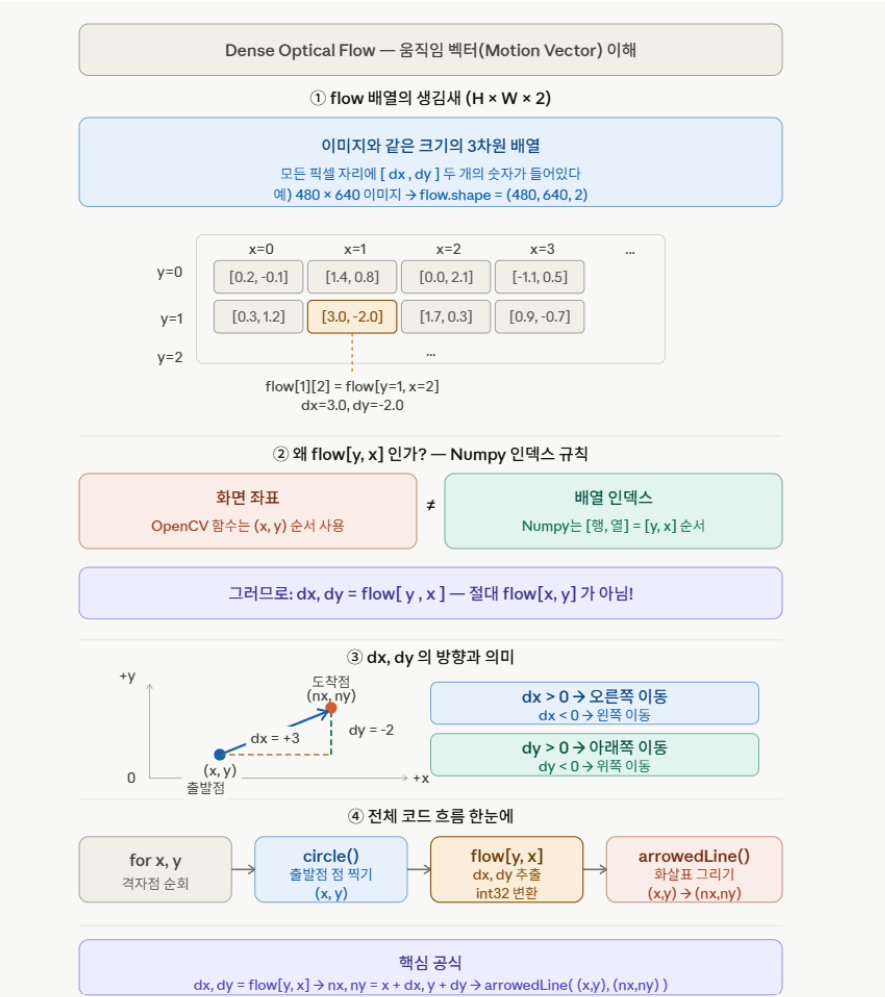

In [ ]:
# 비디오 캠처 설정
video_path = '/content/drive/MyDrive/컴퓨터비전_응용/data/newyork.mp4'

In [ ]:
cap = cv2.VideoCapture(video_path)
delay = int(1000/30)

if not cap.isOpened():
    print('Video open failed!')
    exit()

frame_count = 0
MAX_FRAMES_TO_PROCESS = 150
DISPLAY_EVERY_N_FRAMES = 20

while cap.isOpened() and frame_count < MAX_FRAMES_TO_PROCESS:
    ret, frame = cap.read()
    if not ret:
        print('비디오 스트리밍 종료')
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 최초 프레임의 경우
    if prev is None:
        prev = gray # 첫 프레임을 이전 프레임으로 저장
    else:
        # Farneback Optical flow (Dense optical flow) 계산
        # 모든 픽셀에 대한 움직임 벡터 계산
        # flow 변수 (h, w, 2) 넘파이 배열 >> 각 픽셀의 (dx, dy) 벡터를 담고 있다.
        flow = cv2.calcOpticalFlowFarneback(prev, gray, None,
                                            0.5,    # 이미지 피라미드 스케일(각 단계에서 이미지 50% 축소)
                                            3,      # 피라미드 레벨 수(3단계 피라미드 생성)
                                            15,     # 윈도우 크기(평균 이동을 위한 이웃 픽셀 수)
                                            3,      # 반복 횟수
                                            5,      # 다항식 확장 크기(픽셀 이웃을 다항식으로 근사) ; 테일러 급수
                                            1.1,    # 시그마 값(가우시안 시그마-가우시안 블러 >> 노이즈 제거)
                                            cv2.OPTFLOW_FARNEBACK_GAUSSIAN)
        # 이미지 피라미드
        # 피라미드 레벨 수(3단계 피라미드 생성)
        # 원본 >> 50% >> 25% (큰 움직임도 파악해 냄) (단계별 축소)

        # 윈도우 크기(평균 이동을 위한 이웃 픽셀 수) 15 의미?
        # >> 15px * 15px 영역에서 계산
        # >> 크면, 부드러워지면서 세밀함 감소, 작으면 세밀하지만 노이즈 증가

        # 다항식 확장 크기(픽셀 이웃을 다항식으로 근사)
        # 5의 의미? 5*5 영역 (5: 빠른 처리용, 7: 일반적)

        drawFlow(frame, flow)
        # flow.shape (h, w, 2) >> floww[y, x] = [dx, dy]
        # dx : x 방향 이동 / dy : y 방향 이동

        # 다음 루프를 위해 현재 프레임을 이전 프레임으로 이동
        prev = gray

    if frame_count % DISPLAY_EVERY_N_FRAMES == 0:
        print(f'Frame {frame_count} Farneback 광학 흐름 결과')
        cv2_imshow(frame)   # 추적 결과 프레임 표시
        time.sleep(1)

    frame_count += 1

cap.release()
# cv2.destroyAllWindows()

Output hidden; open in https://colab.research.google.com to view.

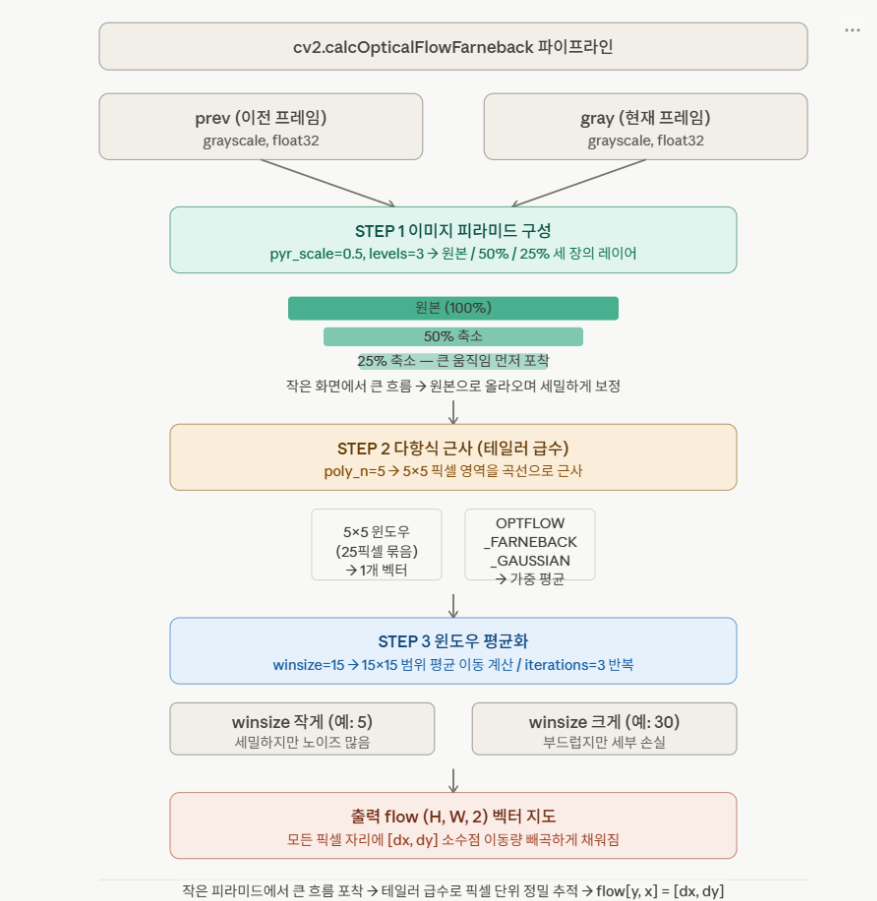

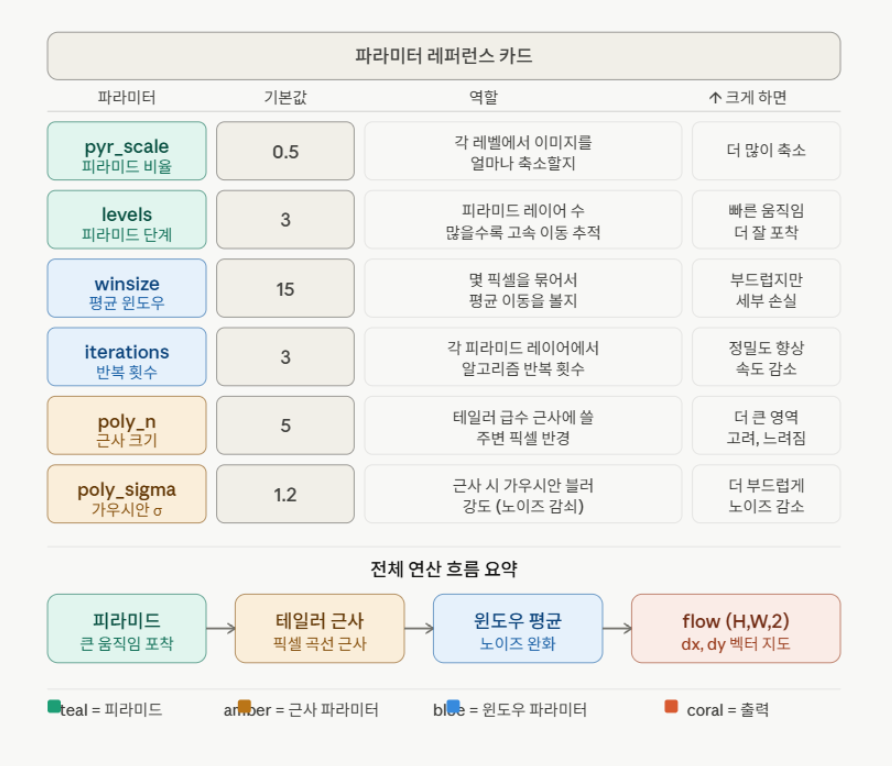

In [ ]:
# 연습
# step_ex = 16
# step_ex //2 # 8

x_idx = [10, 20, 30]
y_idx = [20, 40, 60]

# np.stack((x_idx, y_idx), axis=0)
# 위 아래 쌓은 것(vstack)
# x_idx 0번 행, y_idx 1번 행
'''
array([[10, 20, 30],
       [20, 40, 60]])
'''

# np.stack((x_idx, y_idx), axis=1)
# 서로 다른 열끼리 쌓아서 행을 만들어
# x_idx 0번 열, y_idx 1번 열
'''
array([[10, 20],
       [20, 40],
       [30, 60]])
'''

# np.stack((x_idx, y_idx), axis=-1)
# np.stack((x_idx, y_idx), axis=1) 과 같다
# -1 : 새로운 축을 가장 마지막에 만들어 줌
# >> 1차원 배열일 경우, axis=1

np.stack((x_idx, y_idx), axis=-1).shape # (3,2)
np.stack((x_idx, y_idx), axis=0).shape  # (2,3)

(2, 3)

In [ ]:
index_x = ["나솔1번남자", "나솔2번남자", "나솔3번남자"]
index_y = ["나솔1번여자", "나솔2번여자", "나솔3번여자"]

print(np.stack((index_x, index_y), axis=-1))
print()
print(np.stack((index_x, index_y), axis=1))
# -1 : 줄의 맨 끝(가장 작은 단위), 데이터 안 쪽을 건드려
# 0 : 줄의 맨 앞(가장 큰 단위), 데이터 바깥 쪽 건드려
print()
print(np.stack((index_x, index_y), axis=0))

[['나솔1번남자' '나솔1번여자']
 ['나솔2번남자' '나솔2번여자']
 ['나솔3번남자' '나솔3번여자']]

[['나솔1번남자' '나솔1번여자']
 ['나솔2번남자' '나솔2번여자']
 ['나솔3번남자' '나솔3번여자']]

[['나솔1번남자' '나솔2번남자' '나솔3번남자']
 ['나솔1번여자' '나솔2번여자' '나솔3번여자']]


In [ ]:
# -1 의미
# 데이터 구조 상 가장 최소 단위인 문자열 바로 앞
# 2차원에서 axis=1, axis=-1 이 가장 안쪽 축
# 그래서 결과가 같다.
# >> axis가 2개

# 3차원일 때
# 3차원(행, 열, 채널(깊이)) 2차원 배열을 stack 마지막 차원(깊이) 방향으로 짝을 이룬다.(axis=2)

In [ ]:
# 3차원 예제
# 남자 (기수, 명단)
men =[['9기 1번 남자', '9기 2번 남자'],
      ['10기 1번 남자','10기 2번 남자']]

women =[['9기 1번 여자', '9기 2번 여자'],
      ['10기 1번 여자','10기 2번 여자']]

In [ ]:
print(np.stack((men, women), axis=0))
print()
print(np.stack((men, women), axis=1))
print()
print(np.stack((men, women), axis=2))
print()
print(np.stack((men, women), axis=-1))
# 가장 안쪽을 건드리기 때문에 문자열끼리 1:1 매칭이 된다.

[[['9기 1번 남자' '9기 2번 남자']
  ['10기 1번 남자' '10기 2번 남자']]

 [['9기 1번 여자' '9기 2번 여자']
  ['10기 1번 여자' '10기 2번 여자']]]

[[['9기 1번 남자' '9기 2번 남자']
  ['9기 1번 여자' '9기 2번 여자']]

 [['10기 1번 남자' '10기 2번 남자']
  ['10기 1번 여자' '10기 2번 여자']]]

[[['9기 1번 남자' '9기 1번 여자']
  ['9기 2번 남자' '9기 2번 여자']]

 [['10기 1번 남자' '10기 1번 여자']
  ['10기 2번 남자' '10기 2번 여자']]]

[[['9기 1번 남자' '9기 2번 남자']
  ['10기 1번 남자' '10기 2번 남자']]

 [['9기 1번 여자' '9기 2번 여자']
  ['10기 1번 여자' '10기 2번 여자']]]
